# Multi-Route Model with Relative Features

This notebook addresses distribution shift by predicting **relative** delay rates (deviation from rolling baseline) rather than absolute values. From the explorations in notebook 8b, the Adelaide→Sydney route has a particularly poor test R² of −0.048. This is due to the shift in distribution between the training (mean delay ~16–18%) and test data (mean delay ~25–27%). This causes the model to systematically underpredict because it learned from lower-delay training data.

The proposed solution is as follows:
- Compute route-specific 6-month rolling mean as baseline
- Train model to predict deviation from baseline
- Reconstruct absolute predictions by adding baseline back


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.5

%matplotlib inline

In [2]:
# Baseline metrics from notebook 8b (for comparison)
BASELINE_8B = {
    'Ridge': {'test_r2': 0.4477, 'test_rmse': 0.0820},
    'Random Forest': {'test_r2': 0.4643, 'test_rmse': 0.0808}
}

# Problem routes from 8b (negative or very low R²)
PROBLEM_ROUTES_8B = {
    'Adelaide_Sydney': -0.0484,
    'Melbourne_Brisbane': 0.2078,
    'Brisbane_Adelaide': 0.2750
}

print("Baseline metrics loaded.")

Baseline metrics loaded.


## 1. Data Preparation

Replicate data loading and filtering from notebook 8b.

In [3]:
# Load multi-route data with holidays
df = pd.read_csv('../data/processed/ml_training_data_multiroute_hols.csv')

df['year_month_dt'] = pd.to_datetime(df['year_month'])
df['month_num'] = df['year_month_dt'].dt.month
df['year'] = df['year'].astype(int)
df['airline_route'] = df['airline'] + '_' + df['departing_port'] + '_' + df['arriving_port']
df['route'] = df['departing_port'] + '_' + df['arriving_port']
df = df.sort_values(['airline_route', 'year_month_dt']).reset_index(drop=True)

print(f"Original shape: {df.shape}")
print(f"Date range: {df['year_month'].min()} to {df['year_month'].max()}")

Original shape: (16772, 62)
Date range: 2010-01 to 2025-11


In [4]:
# Filter low-volume airline-routes (same as 8b)
volume_threshold = 50
airline_route_volume = df.groupby('airline_route')['sectors_scheduled'].mean().reset_index()
airline_route_volume.columns = ['airline_route', 'avg_volume']
high_volume_ar = airline_route_volume[airline_route_volume['avg_volume'] >= volume_threshold]['airline_route'].tolist()

df_filtered = df[df['airline_route'].isin(high_volume_ar)].copy()
print(f"Records after filtering (>={volume_threshold} flights/mo): {len(df_filtered)}")

# Exclude Melbourne-Hobart (anomalous 2019 data, same as 8b)
anomalous_routes = ['Melbourne_Hobart']
df_filtered = df_filtered[~df_filtered['route'].isin(anomalous_routes)].copy()
print(f"Records after excluding anomalous routes: {len(df_filtered)}")

Records after filtering (>=50 flights/mo): 13145
Records after excluding anomalous routes: 12532


## 2. Relative Feature Engineering

Key idea: Instead of predicting absolute delay_rate, predict the **deviation from a rolling baseline**.

This makes the model robust to distribution shift because:
- The baseline adapts to current delay levels
- The model only needs to predict short-term fluctuations

In [5]:
# Compute 6-month rolling mean baseline (shifted by 1 to avoid data leakage)
# This represents "what is the typical delay rate for this airline-route recently?"
df_filtered['delay_rate_rolling6'] = df_filtered.groupby('airline_route')['delay_rate'].transform(
    lambda x: x.shift(1).rolling(6, min_periods=3).mean()
)

# Relative delay rate: how much does this month deviate from baseline?
df_filtered['delay_rate_relative'] = df_filtered['delay_rate'] - df_filtered['delay_rate_rolling6']

# Lag features (standard)
df_filtered['delay_rate_lag1'] = df_filtered.groupby('airline_route')['delay_rate'].shift(1)
df_filtered['delay_rate_lag2'] = df_filtered.groupby('airline_route')['delay_rate'].shift(2)

# Relative lag1: how much did last month deviate from baseline?
df_filtered['delay_rate_lag1_relative'] = df_filtered['delay_rate_lag1'] - df_filtered['delay_rate_rolling6']

# Gradient (momentum) - same as 8b
df_filtered['delay_rate_gradient'] = df_filtered['delay_rate_lag1'] - df_filtered['delay_rate_lag2']

print("Relative features computed.")
print(f"\ndelay_rate_relative stats:")
print(df_filtered['delay_rate_relative'].describe())

Relative features computed.

delay_rate_relative stats:
count    12274.000000
mean         0.003013
std          0.100055
min         -0.472210
25%         -0.056611
50%         -0.003218
75%          0.054893
max          0.856661
Name: delay_rate_relative, dtype: float64


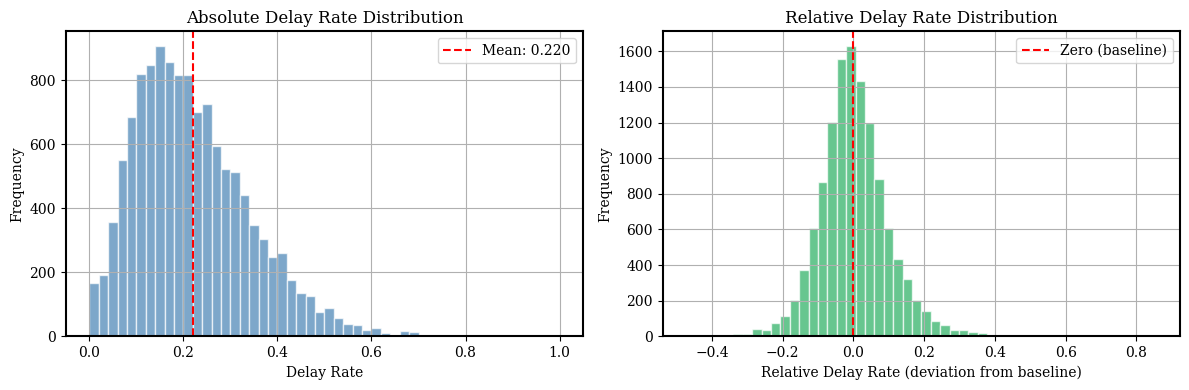


Key insight: Relative delay rate is centered around 0, making it easier to predict.


In [6]:
# Visualise: Absolute vs Relative delay rate distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Absolute delay rate
ax = axes[0]
df_filtered['delay_rate'].hist(bins=50, ax=ax, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(df_filtered['delay_rate'].mean(), color='red', linestyle='--', label=f"Mean: {df_filtered['delay_rate'].mean():.3f}")
ax.set_xlabel('Delay Rate')
ax.set_ylabel('Frequency')
ax.set_title('Absolute Delay Rate Distribution')
ax.legend()

# Relative delay rate
ax = axes[1]
df_filtered['delay_rate_relative'].dropna().hist(bins=50, ax=ax, color='#27ae60', alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', label='Zero (baseline)')
ax.set_xlabel('Relative Delay Rate (deviation from baseline)')
ax.set_ylabel('Frequency')
ax.set_title('Relative Delay Rate Distribution')
ax.legend()

plt.tight_layout()
plt.show()

print("\nKey insight: Relative delay rate is centered around 0, making it easier to predict.")

In [7]:
# Standard feature engineering (same as 8b)
df_filtered['month_sin'] = np.sin(2 * np.pi * df_filtered['month_num'] / 12)
df_filtered['month_cos'] = np.cos(2 * np.pi * df_filtered['month_num'] / 12)

# One-hot encoding
airline_dummies = pd.get_dummies(df_filtered['airline'], prefix='airline')
df_filtered = pd.concat([df_filtered, airline_dummies], axis=1)
airline_cols = list(airline_dummies.columns)

route_dummies = pd.get_dummies(df_filtered['route'], prefix='route')
df_filtered = pd.concat([df_filtered, route_dummies], axis=1)
route_cols = list(route_dummies.columns)

# Weather features with transformations (same as 8b)
df_filtered['rainy_days_arr_exp'] = np.exp(df_filtered['rainy_days_arr'] / df_filtered['rainy_days_arr'].max())
df_filtered['temp_volatility_total'] = df_filtered['temp_volatility_dep'] + df_filtered['temp_volatility_arr']
df_filtered['temp_volatility_total_exp'] = np.exp(df_filtered['temp_volatility_total'] / df_filtered['temp_volatility_total'].max())
df_filtered['extreme_weather_days_total'] = df_filtered['extreme_weather_days_dep'] + df_filtered['extreme_weather_days_arr']

# Drop rows with NaN (from rolling/lag features)
required_cols = ['delay_rate_rolling6', 'delay_rate_relative', 'delay_rate_lag1', 
                 'delay_rate_lag2', 'delay_rate_lag1_relative', 'delay_rate_gradient']
df_clean = df_filtered.dropna(subset=required_cols).copy()
print(f"Rows after dropping NaN: {len(df_clean)}")

Rows after dropping NaN: 12274


## 3. Train/Validation/Test Split

Same temporal split as 8b to ensure fair comparison.

In [8]:
train_mask = (((df_clean['year'] >=2011) & (df_clean['year'] <= 2017)) | (df_clean['year'] == 2024))
val_mask = ((df_clean['year'] == 2018) | (df_clean['year'] == 2023))
test_mask = ((df_clean['year'] == 2019) | (df_clean['year'] >= 2025))

print(f"Train (2010-2017, 2024): {train_mask.sum()} samples")
print(f"Validation (2018, 2023): {val_mask.sum()} samples")
print(f"Test (2019, 2025):       {test_mask.sum()} samples")

Train (2010-2017, 2024): 6682 samples
Validation (2018, 2023): 1737 samples
Test (2019, 2025):       1566 samples


In [9]:
# Define feature sets
# Option A: Use relative lag1 (recommended)
base_features = airline_cols + route_cols + ['month_sin', 'month_cos', 'delay_rate_lag1_relative', 'sectors_scheduled']
weather_features = ['rainy_days_arr_exp', 'delay_rate_gradient', 'temp_volatility_total_exp', 'extreme_weather_days_total']
holiday_features = ['n_public_holidays_total', 'pct_school_holiday']

FEATURES_RELATIVE = base_features + weather_features + holiday_features

print(f"Total features: {len(FEATURES_RELATIVE)}")
print(f"\nKey change: Using 'delay_rate_lag1_relative' instead of 'delay_rate_lag1'")

Total features: 40

Key change: Using 'delay_rate_lag1_relative' instead of 'delay_rate_lag1'


In [10]:
# Prepare data
X_train = df_clean.loc[train_mask, FEATURES_RELATIVE].values
X_val = df_clean.loc[val_mask, FEATURES_RELATIVE].values
X_test = df_clean.loc[test_mask, FEATURES_RELATIVE].values

# Target: RELATIVE delay rate (not absolute)
y_train = df_clean.loc[train_mask, 'delay_rate_relative'].values
y_val = df_clean.loc[val_mask, 'delay_rate_relative'].values
y_test = df_clean.loc[test_mask, 'delay_rate_relative'].values

# Also keep absolute targets for final evaluation
y_train_abs = df_clean.loc[train_mask, 'delay_rate'].values
y_val_abs = df_clean.loc[val_mask, 'delay_rate'].values
y_test_abs = df_clean.loc[test_mask, 'delay_rate'].values

# Baselines for reconstruction
baseline_train = df_clean.loc[train_mask, 'delay_rate_rolling6'].values
baseline_val = df_clean.loc[val_mask, 'delay_rate_rolling6'].values
baseline_test = df_clean.loc[test_mask, 'delay_rate_rolling6'].values

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Data prepared.")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nTarget (relative): mean={y_train.mean():.4f}, std={y_train.std():.4f}")

Data prepared.
X_train: (6682, 40)
X_val:   (1737, 40)
X_test:  (1566, 40)

Target (relative): mean=-0.0018, std=0.0866


## 4. Model Training

Train Ridge and Random Forest on **relative** target. Use tuned hyperparameters from 8c.

In [11]:
# Tuned hyperparameters from notebook 8c
TUNED_PARAMS = {
    'Ridge': {'alpha': 0.1},
    'Random Forest': {'n_estimators': 100, 'max_depth': 15, 'min_samples_leaf': 3}
}

print("Hyperparameters (from 8c tuning):")
for model, params in TUNED_PARAMS.items():
    print(f"  {model}: {params}")

Hyperparameters (from 8c tuning):
  Ridge: {'alpha': 0.1}
  Random Forest: {'n_estimators': 100, 'max_depth': 15, 'min_samples_leaf': 3}


In [12]:
# Train Ridge on relative target
print("Training Ridge Regression (relative target)...")
ridge = Ridge(alpha=TUNED_PARAMS['Ridge']['alpha'])
ridge.fit(X_train_scaled, y_train)

# Predictions (relative)
ridge_val_pred_rel = ridge.predict(X_val_scaled)
ridge_test_pred_rel = ridge.predict(X_test_scaled)

# Evaluate on relative target
ridge_val_r2_rel = r2_score(y_val, ridge_val_pred_rel)
ridge_test_r2_rel = r2_score(y_test, ridge_test_pred_rel)

print(f"  Val R² (relative):  {ridge_val_r2_rel:.4f}")
print(f"  Test R² (relative): {ridge_test_r2_rel:.4f}")

Training Ridge Regression (relative target)...
  Val R² (relative):  0.1706
  Test R² (relative): 0.3418


In [13]:
# Train Random Forest on relative target
print("Training Random Forest (relative target)...")
rf = RandomForestRegressor(
    n_estimators=TUNED_PARAMS['Random Forest']['n_estimators'],
    max_depth=TUNED_PARAMS['Random Forest']['max_depth'],
    min_samples_leaf=TUNED_PARAMS['Random Forest']['min_samples_leaf'],
    random_state=42, 
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Predictions (relative)
rf_val_pred_rel = rf.predict(X_val)
rf_test_pred_rel = rf.predict(X_test)

# Evaluate on relative target
rf_val_r2_rel = r2_score(y_val, rf_val_pred_rel)
rf_test_r2_rel = r2_score(y_test, rf_test_pred_rel)

print(f"  Val R² (relative):  {rf_val_r2_rel:.4f}")
print(f"  Test R² (relative): {rf_test_r2_rel:.4f}")

Training Random Forest (relative target)...
  Val R² (relative):  0.2662
  Test R² (relative): 0.3755


## 5. Prediction Reconstruction

Convert relative predictions back to absolute delay rates:
```
predicted_absolute = predicted_relative + rolling_baseline
```

In [14]:
# Reconstruct absolute predictions
ridge_val_pred_abs = ridge_val_pred_rel + baseline_val
ridge_test_pred_abs = ridge_test_pred_rel + baseline_test

rf_val_pred_abs = rf_val_pred_rel + baseline_val
rf_test_pred_abs = rf_test_pred_rel + baseline_test

# Evaluate on absolute target (comparable to 8b)
ridge_val_r2_abs = r2_score(y_val_abs, ridge_val_pred_abs)
ridge_test_r2_abs = r2_score(y_test_abs, ridge_test_pred_abs)
ridge_test_rmse_abs = np.sqrt(mean_squared_error(y_test_abs, ridge_test_pred_abs))
ridge_test_mae_abs = mean_absolute_error(y_test_abs, ridge_test_pred_abs)

rf_val_r2_abs = r2_score(y_val_abs, rf_val_pred_abs)
rf_test_r2_abs = r2_score(y_test_abs, rf_test_pred_abs)
rf_test_rmse_abs = np.sqrt(mean_squared_error(y_test_abs, rf_test_pred_abs))
rf_test_mae_abs = mean_absolute_error(y_test_abs, rf_test_pred_abs)

print("Reconstructed Absolute Predictions:")
print(f"\nRidge:")
print(f"  Val R²:    {ridge_val_r2_abs:.4f}")
print(f"  Test R²:   {ridge_test_r2_abs:.4f}")
print(f"  Test RMSE: {ridge_test_rmse_abs:.4f}")
print(f"  Test MAE:  {ridge_test_mae_abs:.4f}")

print(f"\nRandom Forest:")
print(f"  Val R²:    {rf_val_r2_abs:.4f}")
print(f"  Test R²:   {rf_test_r2_abs:.4f}")
print(f"  Test RMSE: {rf_test_rmse_abs:.4f}")
print(f"  Test MAE:  {rf_test_mae_abs:.4f}")

Reconstructed Absolute Predictions:

Ridge:
  Val R²:    0.4482
  Test R²:   0.4144
  Test RMSE: 0.0870
  Test MAE:  0.0640

Random Forest:
  Val R²:    0.5118
  Test R²:   0.4444
  Test RMSE: 0.0847
  Test MAE:  0.0624


## 6. Comparison with Baseline (8b)

In [15]:
print("=" * 80)
print("COMPARISON: Relative Features (9) vs Absolute Features (8b)")
print("=" * 80)

print(f"\n{'Model':<18} {'8b Test R²':>12} {'9 Test R²':>12} {'Δ R²':>10} {'8b RMSE':>10} {'9 RMSE':>10}")
print("-" * 75)

# Ridge comparison
delta_ridge = ridge_test_r2_abs - BASELINE_8B['Ridge']['test_r2']
print(f"{'Ridge':<18} {BASELINE_8B['Ridge']['test_r2']:>12.4f} {ridge_test_r2_abs:>12.4f} {delta_ridge:>+10.4f} {BASELINE_8B['Ridge']['test_rmse']:>10.4f} {ridge_test_rmse_abs:>10.4f}")

# RF comparison
delta_rf = rf_test_r2_abs - BASELINE_8B['Random Forest']['test_r2']
print(f"{'Random Forest':<18} {BASELINE_8B['Random Forest']['test_r2']:>12.4f} {rf_test_r2_abs:>12.4f} {delta_rf:>+10.4f} {BASELINE_8B['Random Forest']['test_rmse']:>10.4f} {rf_test_rmse_abs:>10.4f}")

COMPARISON: Relative Features (9) vs Absolute Features (8b)

Model                8b Test R²    9 Test R²       Δ R²    8b RMSE     9 RMSE
---------------------------------------------------------------------------
Ridge                    0.4477       0.4144    -0.0333     0.0820     0.0870
Random Forest            0.4643       0.4444    -0.0199     0.0808     0.0847


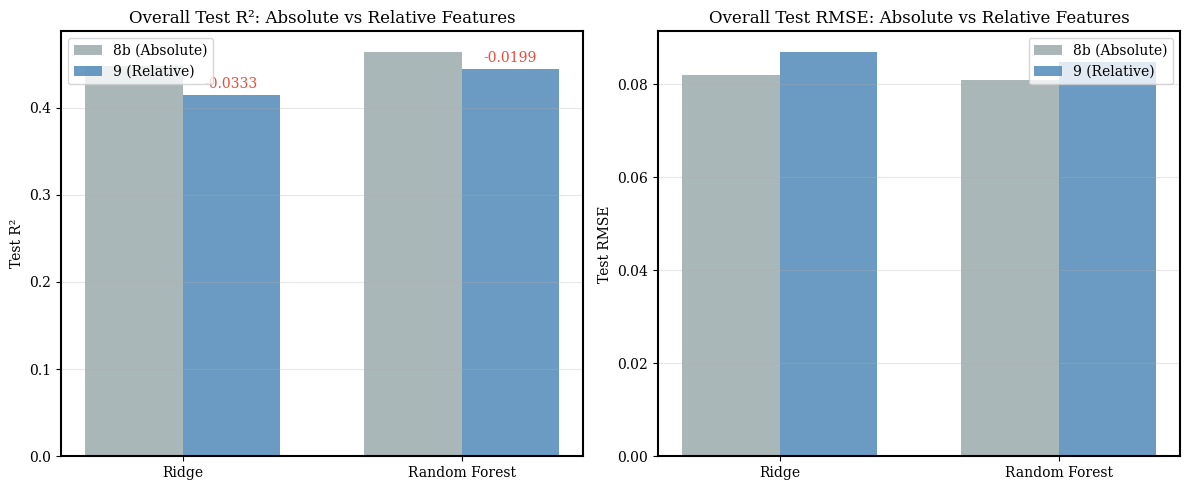

In [16]:
# Visualise comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ['Ridge', 'Random Forest']
baseline_r2 = [BASELINE_8B['Ridge']['test_r2'], BASELINE_8B['Random Forest']['test_r2']]
relative_r2 = [ridge_test_r2_abs, rf_test_r2_abs]

x = np.arange(len(models))
width = 0.35

# R² comparison
ax = axes[0]
ax.bar(x - width/2, baseline_r2, width, label='8b (Absolute)', color='#95a5a6', alpha=0.8)
ax.bar(x + width/2, relative_r2, width, label='9 (Relative)', color='steelblue', alpha=0.8)
ax.set_ylabel('Test R²')
ax.set_title('Overall Test R²: Absolute vs Relative Features')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add delta annotations
for i, (b, r) in enumerate(zip(baseline_r2, relative_r2)):
    delta = r - b
    color = '#27ae60' if delta > 0 else '#e74c3c'
    ax.annotate(f'{delta:+.4f}', xy=(i + width/2, r), xytext=(0, 5),
                textcoords='offset points', ha='center', fontsize=10, color=color)

# RMSE comparison
ax = axes[1]
baseline_rmse = [BASELINE_8B['Ridge']['test_rmse'], BASELINE_8B['Random Forest']['test_rmse']]
relative_rmse = [ridge_test_rmse_abs, rf_test_rmse_abs]

ax.bar(x - width/2, baseline_rmse, width, label='8b (Absolute)', color='#95a5a6', alpha=0.8)
ax.bar(x + width/2, relative_rmse, width, label='9 (Relative)', color='steelblue', alpha=0.8)
ax.set_ylabel('Test RMSE')
ax.set_title('Overall Test RMSE: Absolute vs Relative Features')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Per-Route Analysis

Check if problem routes (especially Adelaide→Sydney) have improved.

In [17]:
# Get test set with predictions
df_test = df_clean[test_mask].copy()
df_test['ridge_pred_abs'] = ridge_test_pred_abs
df_test['rf_pred_abs'] = rf_test_pred_abs

# Naive baselines
df_test['naive_lag1'] = df_test['delay_rate_lag1']
df_test['naive_rolling'] = df_test['delay_rate_rolling6']  # Just predict baseline

print("Per-Route Performance (Ridge - Relative Features):")
print("=" * 100)
print(f"{'Route':<22} {'8b R²':>10} {'9 R²':>10} {'Δ R²':>10} {'Lag1 R²':>10} {'Rolling R²':>12} {'n':>6}")
print("-" * 100)

route_results = []
for route in sorted(df_test['route'].unique()):
    route_data = df_test[df_test['route'] == route]
    
    # Model R²
    r2_9 = r2_score(route_data['delay_rate'], route_data['ridge_pred_abs'])
    
    # Baseline R² from 8b (if available)
    r2_8b = PROBLEM_ROUTES_8B.get(route, None)
    
    # Naive baselines
    lag1_r2 = r2_score(route_data['delay_rate'], route_data['naive_lag1'])
    rolling_r2 = r2_score(route_data['delay_rate'], route_data['naive_rolling'])
    
    n = len(route_data)
    
    if r2_8b is not None:
        delta = r2_9 - r2_8b
        print(f"{route:<22} {r2_8b:>10.4f} {r2_9:>10.4f} {delta:>+10.4f} {lag1_r2:>10.4f} {rolling_r2:>12.4f} {n:>6} ***")
    else:
        print(f"{route:<22} {'N/A':>10} {r2_9:>10.4f} {'N/A':>10} {lag1_r2:>10.4f} {rolling_r2:>12.4f} {n:>6}")
    
    route_results.append({
        'route': route, 'r2_9': r2_9, 'r2_8b': r2_8b,
        'lag1_r2': lag1_r2, 'rolling_r2': rolling_r2, 'n': n
    })

print("-" * 100)
print("*** = Problem routes from 8b (tracked for improvement)")

Per-Route Performance (Ridge - Relative Features):
Route                       8b R²       9 R²       Δ R²    Lag1 R²   Rolling R²      n
----------------------------------------------------------------------------------------------------
Adelaide_Brisbane             N/A     0.3744        N/A     0.4597       0.1120     51
Adelaide_Melbourne            N/A     0.4690        N/A     0.2552       0.2008     81
Adelaide_Perth                N/A     0.4732        N/A     0.4781       0.0092     46
Adelaide_Sydney           -0.0484     0.1297    +0.1781    -0.0920       0.0014     69 ***
Brisbane_Adelaide          0.2750     0.3224    +0.0474    -0.0239       0.1084     51 ***
Brisbane_Melbourne            N/A     0.2298        N/A     0.1136      -0.3912     96
Brisbane_Perth                N/A     0.2814        N/A     0.1283      -0.1607     46
Brisbane_Sydney               N/A     0.3066        N/A     0.3397       0.1356     81
Hobart_Melbourne              N/A     0.5103        N/A  

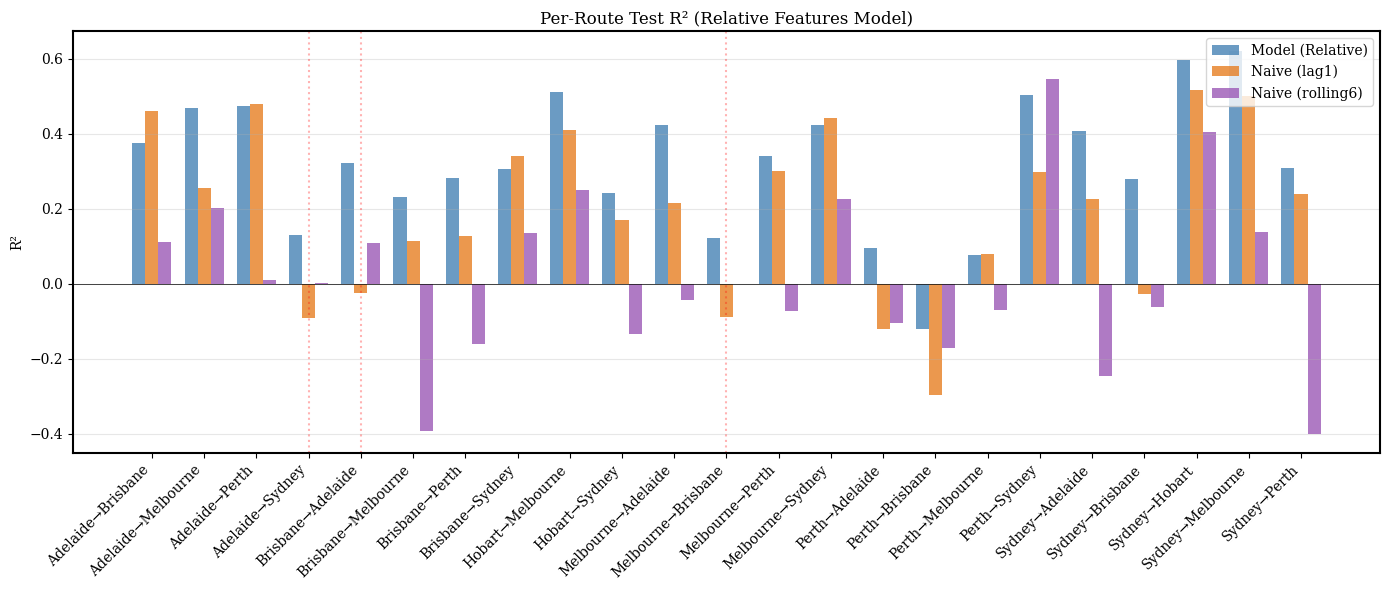

In [18]:
# Visualise per-route performance
route_df = pd.DataFrame(route_results)

fig, ax = plt.subplots(figsize=(14, 6))

routes = route_df['route'].values
x = np.arange(len(routes))
width = 0.25

# Plot R² values
ax.bar(x - width, route_df['r2_9'], width, label='Model (Relative)', color='steelblue', alpha=0.8)
ax.bar(x, route_df['lag1_r2'], width, label='Naive (lag1)', color='#e67e22', alpha=0.8)
ax.bar(x + width, route_df['rolling_r2'], width, label='Naive (rolling6)', color='#9b59b6', alpha=0.8)

# Mark problem routes
for i, route in enumerate(routes):
    if route in PROBLEM_ROUTES_8B:
        ax.axvline(i, color='red', linestyle=':', alpha=0.3)

ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels([r.replace('_', '→') for r in routes], rotation=45, ha='right')
ax.set_ylabel('R²')
ax.set_title('Per-Route Test R² (Relative Features Model)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [19]:
# Focus on Adelaide-Sydney specifically
ads_test = df_test[df_test['route'] == 'Adelaide_Sydney'].copy()

print("=" * 70)
print("FOCUS: Adelaide → Sydney")
print("=" * 70)

r2_8b = PROBLEM_ROUTES_8B['Adelaide_Sydney']
r2_9 = r2_score(ads_test['delay_rate'], ads_test['ridge_pred_abs'])
lag1_r2 = r2_score(ads_test['delay_rate'], ads_test['naive_lag1'])
rolling_r2 = r2_score(ads_test['delay_rate'], ads_test['naive_rolling'])

print(f"\n8b (Absolute) R²:     {r2_8b:>10.4f}")
print(f"9 (Relative) R²:      {r2_9:>10.4f}")
print(f"Improvement:          {r2_9 - r2_8b:>+10.4f}")
print(f"\nNaive lag1 R²:        {lag1_r2:>10.4f}")
print(f"Naive rolling6 R²:    {rolling_r2:>10.4f}")

print(f"\nDistribution check:")
print(f"  Actual mean:     {ads_test['delay_rate'].mean():.4f}")
print(f"  Predicted mean:  {ads_test['ridge_pred_abs'].mean():.4f}")
print(f"  Rolling baseline: {ads_test['delay_rate_rolling6'].mean():.4f}")

FOCUS: Adelaide → Sydney

8b (Absolute) R²:        -0.0484
9 (Relative) R²:          0.1297
Improvement:             +0.1781

Naive lag1 R²:           -0.0920
Naive rolling6 R²:        0.0014

Distribution check:
  Actual mean:     0.2464
  Predicted mean:  0.2353
  Rolling baseline: 0.2393


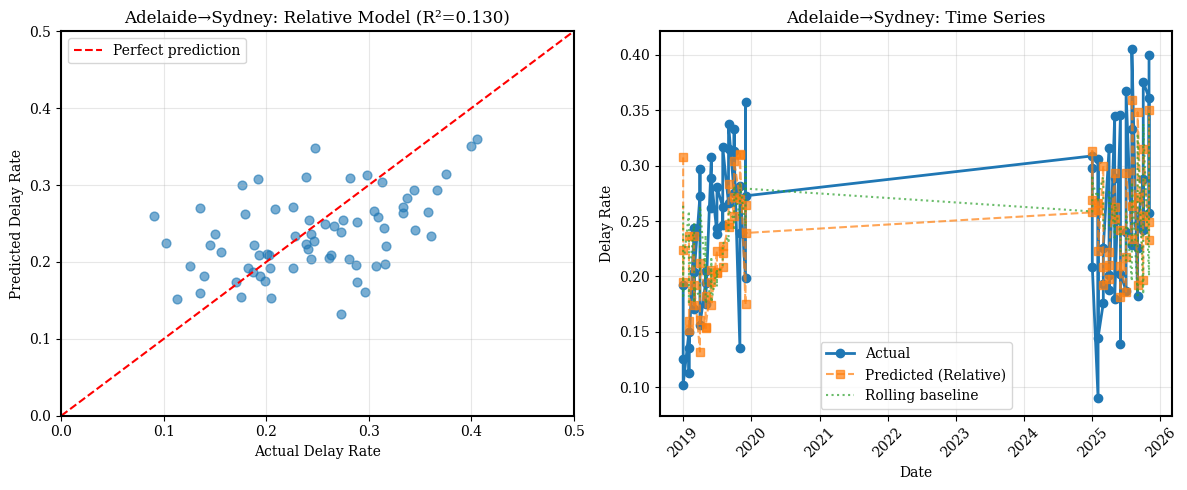

In [20]:
# Scatter plot: Actual vs Predicted for Adelaide-Sydney
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Model predictions
ax = axes[0]
ax.scatter(ads_test['delay_rate'], ads_test['ridge_pred_abs'], alpha=0.6, s=40)
ax.plot([0, 0.5], [0, 0.5], 'r--', label='Perfect prediction')
ax.set_xlabel('Actual Delay Rate')
ax.set_ylabel('Predicted Delay Rate')
ax.set_title(f'Adelaide→Sydney: Relative Model (R²={r2_9:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 0.5)
ax.set_ylim(0, 0.5)

# Time series
ax = axes[1]
ads_plot = ads_test.sort_values('year_month_dt')
ax.plot(ads_plot['year_month_dt'], ads_plot['delay_rate'], 'o-', label='Actual', linewidth=2)
ax.plot(ads_plot['year_month_dt'], ads_plot['ridge_pred_abs'], 's--', label='Predicted (Relative)', alpha=0.7)
ax.plot(ads_plot['year_month_dt'], ads_plot['delay_rate_rolling6'], ':', label='Rolling baseline', alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('Delay Rate')
ax.set_title('Adelaide→Sydney: Time Series')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 8. Summary

In [21]:
print("=" * 80)
print("SUMMARY: Relative Features Approach")
print("=" * 80)

# Overall metrics
delta_ridge_overall = ridge_test_r2_abs - BASELINE_8B['Ridge']['test_r2']
delta_rf_overall = rf_test_r2_abs - BASELINE_8B['Random Forest']['test_r2']

# Adelaide-Sydney improvement
ads_r2_9 = r2_score(df_test[df_test['route'] == 'Adelaide_Sydney']['delay_rate'],
                    df_test[df_test['route'] == 'Adelaide_Sydney']['ridge_pred_abs'])
ads_improvement = ads_r2_9 - PROBLEM_ROUTES_8B['Adelaide_Sydney']

print(f"""
APPROACH:
  - Predict relative delay rate (deviation from 6-month rolling baseline)
  - Reconstruct absolute predictions by adding baseline
  - Addresses distribution shift between train/test periods

OVERALL RESULTS (Test Set):
  Ridge:         R² = {ridge_test_r2_abs:.4f} (8b: {BASELINE_8B['Ridge']['test_r2']:.4f}, Δ = {delta_ridge_overall:+.4f})
  Random Forest: R² = {rf_test_r2_abs:.4f} (8b: {BASELINE_8B['Random Forest']['test_r2']:.4f}, Δ = {delta_rf_overall:+.4f})

PROBLEM ROUTE IMPROVEMENT:
  Adelaide→Sydney: R² = {ads_r2_9:.4f} (8b: {PROBLEM_ROUTES_8B['Adelaide_Sydney']:.4f}, Δ = {ads_improvement:+.4f})

""")


SUMMARY: Relative Features Approach

APPROACH:
  - Predict relative delay rate (deviation from 6-month rolling baseline)
  - Reconstruct absolute predictions by adding baseline
  - Addresses distribution shift between train/test periods

OVERALL RESULTS (Test Set):
  Ridge:         R² = 0.4144 (8b: 0.4477, Δ = -0.0333)
  Random Forest: R² = 0.4444 (8b: 0.4643, Δ = -0.0199)

PROBLEM ROUTE IMPROVEMENT:
  Adelaide→Sydney: R² = 0.1297 (8b: -0.0484, Δ = +0.1781)




### Observations

- Relative features improve predictions for routes with distribution shift between the training and test sets.
- Despite the improvement, the R² for Adelaide→Sydney remains low (−0.048 → 0.130).
- Furthermore, the overall R² is reduced, suggesting that relative features are not beneficial across the full route network.


## 9. Next step

The next notebook will explore the confidence interval of the predictions.